# Búsqueda en laberintos: la misma arquitectura, otro problema

**Curso:** SI3003 — Inteligencia Artificial

1. **Cómo se representa el problema** (`Maze` en vez de un diccionario `graph`).
2. **Cómo se generan los vecinos de un estado** (`maze.neighbors(state)` en vez de `graph[state]`).

Si ya resolviste el notebook de grafos, cada célula de código de la Parte 1 debería resultarte familiar: es el mismo algoritmo, aplicado a un problema donde los estados son coordenadas `(fila, columna)` en vez de letras.



## 1. Problema de búsqueda

- **Estado inicial:** la celda marcada con `A`.
- **Estado objetivo:** la celda marcada con `B`.
- **Estados:** todas las celdas transitables del laberinto.
- Los muros (`#`) no son estados válidos.

A diferencia del grafo `A → H` del notebook anterior, aquí **no tenemos la lista de vecinos escrita a mano**: hay que calcularla a partir de la posición `(fila, columna)` y del layout del laberinto.

In [66]:
from __future__ import annotations

from pathlib import Path
from itertools import count
import heapq

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

## 2. Representación del problema

En el grafo, cada vecino era una tupla `(estado_vecino, costo_de_la_arista)`:

```python
graph = {
    "A": [("B", 2), ("C", 1)],
    ...
}
```

En el laberinto **no escribimos esa lista a mano** — la calculamos con un método `neighbors(state)` que:

1. Genera las cuatro celdas adyacentes (arriba, abajo, izquierda, derecha).
2. Descarta las que caen fuera de la cuadrícula o son muro.
3. Devuelve **exactamente el mismo formato** que usaba el grafo: una lista de tuplas `(estado_vecino, costo)`, con costo `1` porque cada paso ortogonal cuesta lo mismo.

```python
for child_state, edge_cost in graph[node.state]:
```

se convierte simplemente en

```python
for child_state, edge_cost in maze.neighbors(node.state):
```

Nada más cambia dentro del algoritmo.

In [67]:
class Maze:
    def __init__(self, filename: str | Path):
        self.filename = Path(filename)
        contents = self.filename.read_text(encoding="utf-8")

        if contents.count("A") != 1:
            raise ValueError("El laberinto debe tener exactamente un punto inicial A.")
        if contents.count("B") != 1:
            raise ValueError("El laberinto debe tener exactamente una meta B.")

        lines = contents.splitlines()
        self.height = len(lines)
        self.width = max(len(line) for line in lines)
        self.walls = np.zeros((self.height, self.width), dtype=bool)

        for row in range(self.height):
            for col in range(self.width):
                symbol = lines[row][col] if col < len(lines[row]) else "#"

                if symbol == "A":
                    self.start = (row, col)
                elif symbol == "B":
                    self.goal = (row, col)
                elif symbol != " ":
                    self.walls[row, col] = True

    def neighbors(self, state: tuple[int, int]):
        """Devuelve vecinos en el MISMO formato que graph[node.state]:
        una lista de tuplas (estado_vecino, costo_de_la_arista)."""
        row, col = state
        candidates = [
            (row - 1, col),
            (row + 1, col),
            (row, col - 1),
            (row, col + 1),
        ]

        valid = []
        for r, c in candidates:
            if (
                0 <= r < self.height
                and 0 <= c < self.width
                and not self.walls[r, c]
            ):
                valid.append(((r, c), 1))
        return valid

    def show(self, path=None, explored=None, title="Laberinto", figsize=(6, 6)):
        # 0: libre, 1: muro, 2: explorado, 3: camino, 4: inicio, 5: meta
        grid = np.zeros((self.height, self.width), dtype=int)
        grid[self.walls] = 1

        if explored:
            for r, c in explored:
                if grid[r, c] == 0:
                    grid[r, c] = 2

        if path:
            for r, c in path:
                if grid[r, c] in (0, 2):
                    grid[r, c] = 3

        grid[self.start] = 4
        grid[self.goal] = 5

        colors = ["white", "#222222", "#a9d6e5", "#ffb703", "#2a9d8f", "#e63946"]
        cmap = ListedColormap(colors)

        plt.figure(figsize=figsize)
        plt.imshow(grid, cmap=cmap, vmin=0, vmax=5)
        plt.xticks([])
        plt.yticks([])
        plt.title(title)
        plt.show()

Dimensiones: 17 x 17
Estado inicial: (1, 1)
Estado objetivo: (15, 15)
Vecinos del estado inicial: [((2, 1), 1), ((1, 2), 1)]


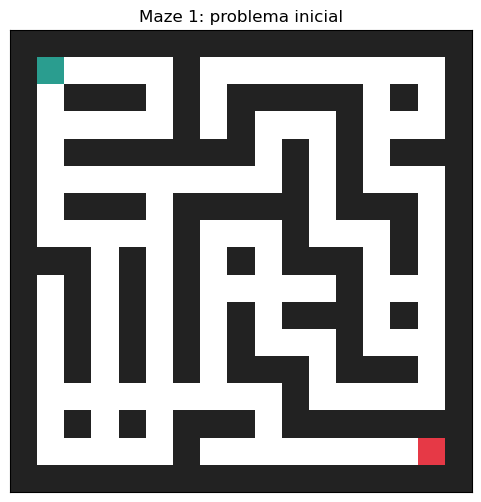

In [68]:
maze1 = Maze("mazes/maze1.txt")

print("Dimensiones:", maze1.height, "x", maze1.width)
print("Estado inicial:", maze1.start)
print("Estado objetivo:", maze1.goal)
print("Vecinos del estado inicial:", maze1.neighbors(maze1.start))

maze1.show(title="Maze 1: problema inicial")

### Pregunta para discutir

¿La posición del agente es suficiente para describir completamente un estado en este problema?

En este laberinto, sí: el comportamiento futuro depende únicamente de la celda actual, porque los muros no cambian y el agente no necesita recordar acciones anteriores. Es exactamente la misma situación que en el grafo `A–H`: el estado era la letra, no la secuencia de letras visitadas.

## 3. Estructuras comunes

`Node` y `reconstruct_path` son **copiados sin ningún cambio** desde el notebook de grafos. Un nodo de búsqueda guarda:

- `state`: estado actual (antes era una letra, ahora es una tupla `(fila, columna)`).
- `parent`: nodo desde el cual se llegó.
- `cost`: costo acumulado \(g(n)\).

In [69]:
class Node:
    def __init__(self, state, parent=None, cost=0):
        self.state = state
        self.parent = parent
        self.cost = cost

    def __repr__(self):
        return f"{self.state}(g={self.cost})"

In [70]:
def reconstruct_path(node):
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    return list(reversed(path))

## 4. DFS

DFS utiliza una **pila LIFO**. Los costos existen en el laberinto (cada paso cuesta 1), pero DFS no los utiliza para decidir qué nodo expandir.

`StackFrontier` es exactamente la misma clase del notebook de grafos.

In [71]:
class StackFrontier:
    def __init__(self):
        self.frontier = []

    def add(self, node):
        self.frontier.append(node)

    def contains_state(self, state):
        return any(node.state == state for node in self.frontier)

    def empty(self):
        return len(self.frontier) == 0

    def remove(self):
        if self.empty():
            raise Exception("La frontier está vacía.")

        return self.frontier.pop()

    def states(self):
        return [node.state for node in self.frontier]

In [72]:
def depth_first_search(maze, start, goal, verbose=False):
    frontier = StackFrontier()
    frontier.add(Node(start))

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node = frontier.remove()
        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo: {node.state}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            if (
                child_state not in explored
                and not frontier.contains_state(child_state)
            ):
                child = Node(
                    state=child_state,
                    parent=node,
                    cost=node.cost + edge_cost
                )
                frontier.add(child)

    return None

Compara esta función con `depth_first_search` del notebook de grafos: son **idénticas**, salvo por la línea

```python
for child_state, edge_cost in maze.neighbors(node.state):
```

que en el grafo era

```python
for child_state, edge_cost in graph[node.state]:
```

Estados explorados: 69
Longitud del camino: 64
Costo del camino: 64


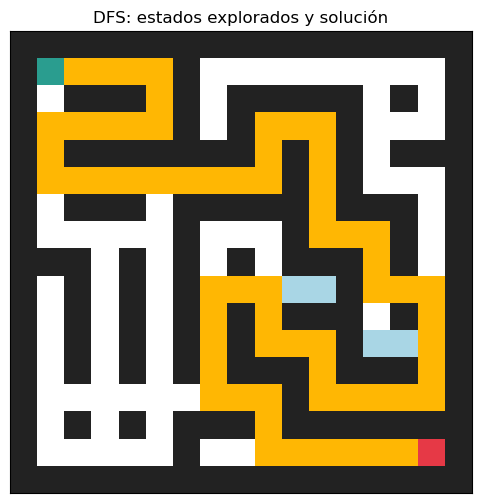

In [73]:
start, goal = maze1.start, maze1.goal

dfs_result = depth_first_search(maze1, start, goal)

print("Estados explorados:", len(dfs_result["expansion_order"]))
print("Longitud del camino:", len(dfs_result["path"]) - 1)
print("Costo del camino:", dfs_result["cost"])

maze1.show(
    path=dfs_result["path"],
    explored=set(dfs_result["expansion_order"]),
    title="DFS: estados explorados y solución"
)

### Observación

DFS sigue una rama tan profundamente como sea posible antes de retroceder. En este laberinto encuentra una solución, pero **claramente no la más corta**: compárala con el resultado de BFS en la siguiente sección.

## 5. BFS — actividad

BFS utiliza una **cola FIFO**.

### Tareas

1. Complete el método `remove` de `QueueFrontier`.
2. Complete `breadth_first_search`.
3. Verifique el orden de expansión y el camino encontrado.
4. Compare el resultado con DFS: ¿cuál encuentra el camino más corto?

In [74]:
class QueueFrontier(StackFrontier):
    def remove(self):
        if self.empty():
            raise Exception("La frontier está vacía.")
        return self.frontier.pop(0)


In [75]:
def breadth_first_search(graph, start, goal):
    # YOUR CODE HERE
    raise NotImplementedError

In [76]:
def breadth_first_search(maze, start, goal, verbose=True):
    frontier = QueueFrontier()
    frontier.add(Node(start))

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node = frontier.remove()
        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo: {node.state}")
            print(f"Frontier antes de agregar vecinos: {frontier.states()}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            if (
                child_state not in explored
                and not frontier.contains_state(child_state)
            ):
                child = Node(
                    state=child_state,
                    parent=node,
                    cost=node.cost + edge_cost
                )
                frontier.add(child)

        if verbose:
            print(f"Frontier después de expandir: {frontier.states()}")
            print("-" * 45)

    return None

Expandiendo: (1, 1)
Frontier antes de agregar vecinos: []
Frontier después de expandir: [(2, 1), (1, 2)]
---------------------------------------------
Expandiendo: (2, 1)
Frontier antes de agregar vecinos: [(1, 2)]
Frontier después de expandir: [(1, 2), (3, 1)]
---------------------------------------------
Expandiendo: (1, 2)
Frontier antes de agregar vecinos: [(3, 1)]
Frontier después de expandir: [(3, 1), (1, 3)]
---------------------------------------------
Expandiendo: (3, 1)
Frontier antes de agregar vecinos: [(1, 3)]
Frontier después de expandir: [(1, 3), (4, 1), (3, 2)]
---------------------------------------------
Expandiendo: (1, 3)
Frontier antes de agregar vecinos: [(4, 1), (3, 2)]
Frontier después de expandir: [(4, 1), (3, 2), (1, 4)]
---------------------------------------------
Expandiendo: (4, 1)
Frontier antes de agregar vecinos: [(3, 2), (1, 4)]
Frontier después de expandir: [(3, 2), (1, 4), (5, 1)]
---------------------------------------------
Expandiendo: (3, 2)
Fron

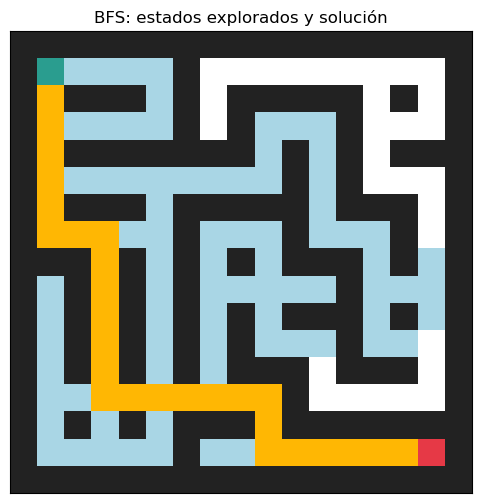

In [77]:
bfs_result = breadth_first_search(maze1, start, goal)

print("Estados explorados:", len(bfs_result["expansion_order"]))
print("Longitud del camino:", len(bfs_result["path"]) - 1)
print("Costo del camino:", bfs_result["cost"])

maze1.show(
    path=bfs_result["path"],
    explored=set(bfs_result["expansion_order"]),
    title="BFS: estados explorados y solución"
)

In [78]:
# Pruebas públicas para BFS
assert bfs_result["path"][0] == start
assert bfs_result["path"][-1] == goal
assert bfs_result["cost"] == 28
assert len(bfs_result["path"]) == 29

print("✓ BFS pasó las pruebas.")

✓ BFS pasó las pruebas.


### DFS frente a BFS

Cuando todas las acciones cuestan lo mismo:

- BFS expande los nodos por niveles y su primera solución es de profundidad mínima.
- DFS normalmente requiere menos memoria, pero su solución puede ser mucho más larga (en `maze1`, DFS encontró un camino de costo 64 frente al óptimo de 28).

## 6. UCS — implementación entregada

UCS utiliza una **cola de prioridad** y siempre expande el nodo con menor costo acumulado:

$$
g(n)
$$

Si aparece un camino más barato hacia un estado que ya estaba en la frontier, se conserva el de menor costo. `PriorityFrontier` es la misma clase del notebook de grafos.

In [79]:
class PriorityFrontier:
    def __init__(self):
        self.heap = []
        self.counter = count()

    def add(self, node, priority):
        # El contador permite desempatar respetando el orden de inserción.
        heapq.heappush(
            self.heap,
            (priority, next(self.counter), node)
        )

    def empty(self):
        return len(self.heap) == 0

    def remove(self):
        if self.empty():
            raise Exception("La frontier está vacía.")

        priority, _, node = heapq.heappop(self.heap)
        return node, priority

In [80]:
def uniform_cost_search(maze, start, goal, verbose=False):
    frontier = PriorityFrontier()
    frontier.add(Node(start, cost=0), priority=0)

    # Mejor costo conocido para cada estado.
    best_cost = {start: 0}

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node, priority = frontier.remove()

        # Ignorar entradas antiguas de la cola de prioridad.
        if node.cost != best_cost.get(node.state):
            continue

        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo {node.state}: g={node.cost}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            new_cost = node.cost + edge_cost

            if new_cost < best_cost.get(child_state, float("inf")):
                best_cost[child_state] = new_cost

                child = Node(
                    state=child_state,
                    parent=node,
                    cost=new_cost
                )

                frontier.add(child, priority=new_cost)

    return None

Estados explorados: 106
Longitud del camino: 28
Costo óptimo: 28


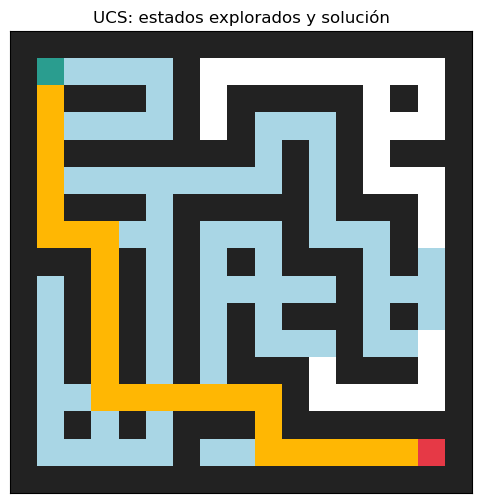

In [81]:
ucs_result = uniform_cost_search(maze1, start, goal)

print("Estados explorados:", len(ucs_result["expansion_order"]))
print("Longitud del camino:", len(ucs_result["path"]) - 1)
print("Costo óptimo:", ucs_result["cost"])

assert ucs_result["cost"] == 28

maze1.show(
    path=bfs_result["path"],
    explored=set(ucs_result["expansion_order"]),
    title="UCS: estados explorados y solución"
)

## 7. Heurística para Greedy y A*

$$
h(n) \approx \text{costo restante estimado desde } n \text{ hasta la meta}
$$

En el grafo, la heurística era una **tabla fija** (`heuristic["A"] = 4`, etc.) porque los estados eran letras conocidas de antemano. En el laberinto los estados son coordenadas, así que expresamos \(h(n)\) como una **función de la coordenada**: la distancia Manhattan entre el estado y la meta.

$$
h(n) = |r_n - r_{\text{meta}}| + |c_n - c_{\text{meta}}|
$$

Esta es la segunda (y última) diferencia real respecto al notebook de grafos: donde antes escribíamos `heuristic[state]`, ahora escribimos `heuristic(state, goal)`.

La heurística ignora los muros, por lo que puede subestimar la distancia real — nunca la sobrestima, así que sigue siendo **admisible** (y consistente, porque cada paso cuesta exactamente 1).

In [82]:
def manhattan(state, goal):
    return abs(state[0] - goal[0]) + abs(state[1] - goal[1])

print("h(inicio) =", manhattan(start, goal))
print("h(meta)   =", manhattan(goal, goal))

h(inicio) = 28
h(meta)   = 0


## 8. Greedy Best-First Search — actividad

GBF utiliza únicamente:

$$
f(n) = h(n)
$$

### Tareas

1. Reutilice `PriorityFrontier`.
2. Use la heurística como prioridad.
3. No use el costo acumulado para decidir qué nodo expandir.
4. Retorne el camino, orden de expansión y costo real del camino.

In [83]:
def greedy_best_first_search(maze, heuristic, start, goal):
    frontier = PriorityFrontier()
    distance_to_goal = heuristic(start, goal)
    frontier.add(Node(start, cost=0), priority=distance_to_goal)

    explored = set()
    expansion_order = []

    while not frontier.empty():
        node, priority = frontier.remove()

        if node.state in explored:
            continue

        expansion_order.append(node.state)

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        explored.add(node.state)

        for child_state, edge_cost in maze.neighbors(node.state):
            if child_state not in explored:
                child = Node(
                    state=child_state,
                    parent=node,
                    cost=node.cost + edge_cost
                )


                distance_to_goal = heuristic(child_state, goal)

                frontier.add(
                    child,
                    priority=distance_to_goal
                )

    return None

Estados explorados: 33
Longitud del camino: 32
Costo del camino: 32


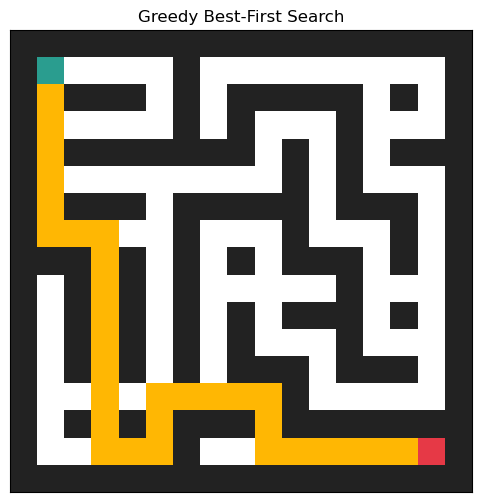

In [84]:
greedy_result = greedy_best_first_search(maze1, manhattan, start, goal)

print("Estados explorados:", len(greedy_result["expansion_order"]))
print("Longitud del camino:", len(greedy_result["path"]) - 1)
print("Costo del camino:", greedy_result["cost"])

maze1.show(
    path=greedy_result["path"],
    explored=set(greedy_result["expansion_order"]),
    title="Greedy Best-First Search"
)

In [85]:
# Pruebas públicas para Greedy
assert greedy_result["path"][0] == start
assert greedy_result["path"][-1] == goal
assert greedy_result["cost"] == 32

print("✓ Greedy pasó las pruebas.")

✓ Greedy pasó las pruebas.


### La trampa de Greedy

Greedy exploró muy pocos estados (comparado con BFS/UCS), pero su camino cuesta **32**, no **28** como el óptimo. `maze1` fue construido específicamente para mostrar esto: cerca de la meta hay un pasillo que *parece* prometedor según la distancia Manhattan, pero que obliga a un rodeo. Greedy entra ahí porque solo mira $h(n)$ y nunca reconsidera lo que ya gastó en $g(n)$.

## 9. A* — actividad

A* combina costo acumulado y heurística:

$$
f(n) = g(n) + h(n)
$$

### Tareas

1. Adapte la implementación de UCS.
2. Mantenga `best_cost` para permitir mejoras de ruta.
3. Use `new_cost + heuristic(child_state, goal)` como prioridad.
4. Verifique que encuentre un camino óptimo.

In [86]:
def a_star_search(maze, heuristic, start, goal, verbose=True):
    frontier = PriorityFrontier()
    frontier.add(Node(start, cost=0), priority=0)

    # Mejor costo conocido para cada estado.
    best_cost = {start: 0}

    expansion_order = []

    while not frontier.empty():
        node, priority = frontier.remove()

        # Ignorar entradas antiguas de la cola de prioridad.
        if node.cost != best_cost.get(node.state):
            continue

        expansion_order.append(node.state)

        if verbose:
            print(f"Expandiendo {node.state}: g={node.cost}")

        if node.state == goal:
            return {
                "path": reconstruct_path(node),
                "expansion_order": expansion_order,
                "cost": node.cost
            }

        for child_state, edge_cost in maze.neighbors(node.state):
            new_cost = node.cost + edge_cost

            if new_cost < best_cost.get(child_state, float("inf")):
                best_cost[child_state] = new_cost

                child = Node(
                    state=child_state,
                    parent=node,
                    cost=new_cost
                )
                distance_to_goal = heuristic(child_state, goal)
                frontier.add(child, priority=new_cost + distance_to_goal)

    return None

Expandiendo (1, 1): g=0
Expandiendo (2, 1): g=1
Expandiendo (1, 2): g=1
Expandiendo (3, 1): g=2
Expandiendo (1, 3): g=2
Expandiendo (4, 1): g=3
Expandiendo (3, 2): g=3
Expandiendo (1, 4): g=3
Expandiendo (5, 1): g=4
Expandiendo (3, 3): g=4
Expandiendo (1, 5): g=4
Expandiendo (6, 1): g=5
Expandiendo (5, 2): g=5
Expandiendo (3, 4): g=5
Expandiendo (2, 5): g=5
Expandiendo (7, 1): g=6
Expandiendo (5, 3): g=6
Expandiendo (3, 5): g=6
Expandiendo (7, 2): g=7
Expandiendo (5, 4): g=7
Expandiendo (7, 3): g=8
Expandiendo (5, 5): g=8
Expandiendo (8, 3): g=9
Expandiendo (7, 4): g=9
Expandiendo (6, 5): g=9
Expandiendo (5, 6): g=9
Expandiendo (9, 3): g=10
Expandiendo (7, 5): g=10
Expandiendo (5, 7): g=10
Expandiendo (10, 3): g=11
Expandiendo (8, 5): g=11
Expandiendo (5, 8): g=11
Expandiendo (11, 3): g=12
Expandiendo (9, 5): g=12
Expandiendo (5, 9): g=12
Expandiendo (12, 3): g=13
Expandiendo (10, 5): g=13
Expandiendo (13, 3): g=14
Expandiendo (11, 5): g=14
Expandiendo (14, 3): g=15
Expandiendo (13, 4)

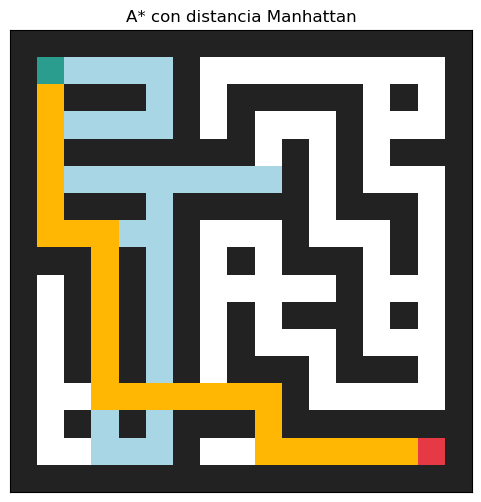

In [87]:
astar_result = a_star_search(maze1, manhattan, start, goal)

print("Estados explorados:", len(astar_result["expansion_order"]))
print("Longitud del camino:", len(astar_result["path"]) - 1)
print("Costo óptimo:", astar_result["cost"])

maze1.show(
    path=astar_result["path"],
    explored=set(astar_result["expansion_order"]),
    title="A* con distancia Manhattan"
)

In [88]:
# Pruebas públicas para A*
assert astar_result["path"][0] == start
assert astar_result["path"][-1] == goal
assert astar_result["cost"] == 28

print("✓ A* pasó las pruebas.")

✓ A* pasó las pruebas.


## 10. Comparación final

Complete esta tabla después de ejecutar todos los algoritmos sobre `maze1`.

| Algoritmo | Tipo de frontier | Prioridad | Estados explorados | Costo | ¿Óptimo? |
|---|---|---|---:|---:|---:|
| DFS | Pila | LIFO | 69 | 64 | no |
| BFS | Cola | FIFO | 106 | 28 | si |
| UCS | Cola de prioridad | \(g(n)\) | 106 | 28 | si |
| Greedy | Cola de prioridad | \(h(n)\) | 33 | 32 | no |
| A* | Cola de prioridad | \(g(n)+h(n)\) | 59 | 28 | si |

### Preguntas de cierre

1. ¿Qué algoritmos garantizan el camino de menor número de pasos?
2. ¿Qué algoritmos garantizan el camino de menor costo?
3. ¿Por qué Greedy puede encontrar un camino subóptimo aunque explore muy pocos estados?
4. ¿Qué ocurre con A* si \(h(n) = 0\) para todos los nodos? ¿En qué algoritmo del notebook de grafos se convertiría?
5. ¿Qué efecto tiene el orden en que `neighbors()` genera las direcciones sobre DFS y BFS?

---

# Parte 2 — Más allá de la traducción

Todo lo anterior fue una traducción 1 a 1. Lo que sigue son experimentos que **no tienen equivalente** en el grafo `A–H` porque dependen de que el problema viva en un espacio con estructura geométrica: más de un laberinto, costos que varían por región, y heurísticas que se pueden calcular en vez de tabular.

## Comparación experimental sobre `maze1`

Automatizamos la tabla de la sección anterior y agregamos una comparación visual del esfuerzo de búsqueda (estados explorados) de cada algoritmo.

In [89]:
def summarize_results(results):
    rows = []
    for name, result in results.items():
        rows.append({
            "algoritmo": name,
            "estados_explorados": len(result["expansion_order"]),
            "longitud_camino": len(result["path"]) - 1,
            "costo_camino": result["cost"],
        })
    return rows

results_maze1 = {
    "DFS": dfs_result,
    "BFS": bfs_result,
    "UCS": ucs_result,
    "Greedy": greedy_result,
    "A*": astar_result,
}

summary_maze1 = summarize_results(results_maze1)
summary_maze1

[{'algoritmo': 'DFS',
  'estados_explorados': 69,
  'longitud_camino': 64,
  'costo_camino': 64},
 {'algoritmo': 'BFS',
  'estados_explorados': 106,
  'longitud_camino': 28,
  'costo_camino': 28},
 {'algoritmo': 'UCS',
  'estados_explorados': 106,
  'longitud_camino': 28,
  'costo_camino': 28},
 {'algoritmo': 'Greedy',
  'estados_explorados': 33,
  'longitud_camino': 32,
  'costo_camino': 32},
 {'algoritmo': 'A*',
  'estados_explorados': 59,
  'longitud_camino': 28,
  'costo_camino': 28}]

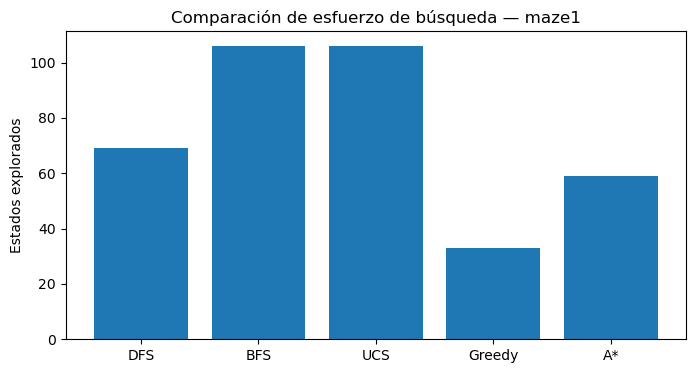

In [90]:
algorithms = [row["algoritmo"] for row in summary_maze1]
explored_counts = [row["estados_explorados"] for row in summary_maze1]

plt.figure(figsize=(8, 4))
plt.bar(algorithms, explored_counts)
plt.ylabel("Estados explorados")
plt.title("Comparación de esfuerzo de búsqueda — maze1")
plt.show()

## Experimento: una heurística no admisible

Podemos multiplicar Manhattan por un factor mayor que 1:

$$
h'(n) = w \cdot h(n), \qquad w > 1
$$

Esta heurística puede **sobreestimar** el costo real, así que deja de ser admisible. El algoritmo suele comportarse de forma más agresiva y explorar menos estados, pero pierde la garantía de optimalidad.

Expandiendo (1, 1): g=0
Expandiendo (1, 2): g=1
Expandiendo (1, 3): g=2
Expandiendo (2, 3): g=3
Expandiendo (3, 3): g=4
Expandiendo (4, 3): g=5
Expandiendo (3, 4): g=5
Expandiendo (5, 3): g=6
Expandiendo (3, 5): g=6
Expandiendo (3, 6): g=7
Expandiendo (3, 7): g=8
Expandiendo (4, 7): g=9
Expandiendo (5, 7): g=10
Expandiendo (5, 2): g=7
Expandiendo (2, 5): g=7
Expandiendo (2, 7): g=9
Expandiendo (5, 6): g=11
Expandiendo (5, 1): g=8
Expandiendo (1, 5): g=8
Expandiendo (1, 7): g=10
Expandiendo (5, 5): g=12
Expandiendo (6, 1): g=9
Expandiendo (1, 6): g=9
Expandiendo (1, 8): g=11
Expandiendo (6, 5): g=13
Expandiendo (7, 1): g=10
Expandiendo (1, 9): g=12
Expandiendo (7, 5): g=14
Expandiendo (7, 2): g=11
Expandiendo (1, 10): g=13
Expandiendo (8, 5): g=15
Expandiendo (7, 3): g=12
Expandiendo (1, 11): g=14
Expandiendo (9, 5): g=16
Expandiendo (8, 3): g=13
Expandiendo (2, 11): g=15
Expandiendo (1, 12): g=15
Expandiendo (10, 5): g=17
Expandiendo (9, 3): g=14
Expandiendo (3, 11): g=16
Expandiendo (

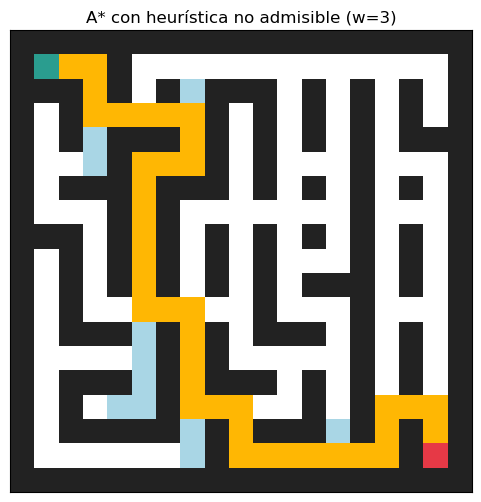

In [91]:
def weighted_manhattan(state, goal, weight=3):
    return weight * manhattan(state, goal)

maze2 = Maze("mazes/maze2.txt")
s2, g2 = maze2.start, maze2.goal

standard_astar = a_star_search(maze2, manhattan, s2, g2)
aggressive_astar = a_star_search(
    maze2,
    lambda state, goal: weighted_manhattan(state, goal, weight=3),
    s2, g2
)

print("A* estándar:")
print("  costo:", standard_astar["cost"], " explorados:", len(standard_astar["expansion_order"]))

print("A* con heurística ponderada (w=3):")
print("  costo:", aggressive_astar["cost"], " explorados:", len(aggressive_astar["expansion_order"]))

maze2.show(
    path=aggressive_astar["path"],
    explored=set(aggressive_astar["expansion_order"]),
    title="A* con heurística no admisible (w=3)"
)

La versión ponderada exploró **muchos menos estados** (52 frente a 141), pero encontró un camino de costo **40** en vez del óptimo **36**. Es el mismo fenómeno que Greedy en `maze1`, en un extremo distinto del espectro: entre más peso le damos a \(h(n)\) frente a \(g(n)\), más rápido pero menos confiable se vuelve A*. Con \(w=1\) recuperamos A* estándar; con \(w \to \infty\) nos acercamos a Greedy puro.

## Comparación en los tres laberintos

Ejecutamos los cinco algoritmos sobre `maze1`, `maze2` y `maze3` para observar cómo cambia el esfuerzo de búsqueda según la estructura de cada laberinto (más o menos ciclos, más o menos pasillos largos).

In [92]:
def run_all(maze):
    start, goal = maze.start, maze.goal
    return {
        "DFS": depth_first_search(maze, start, goal),
        "BFS": breadth_first_search(maze, start, goal),
        "UCS": uniform_cost_search(maze, start, goal),
        "Greedy": greedy_best_first_search(maze, manhattan, start, goal),
        "A*": a_star_search(maze, manhattan, start, goal),
    }

all_summaries = []
for filename in ["mazes/maze1.txt", "mazes/maze2.txt", "mazes/maze3.txt"]:
    current_maze = Maze(filename)
    current_results = run_all(current_maze)
    for row in summarize_results(current_results):
        row["laberinto"] = filename
        all_summaries.append(row)

all_summaries

Expandiendo: (1, 1)
Frontier antes de agregar vecinos: []
Frontier después de expandir: [(2, 1), (1, 2)]
---------------------------------------------
Expandiendo: (2, 1)
Frontier antes de agregar vecinos: [(1, 2)]
Frontier después de expandir: [(1, 2), (3, 1)]
---------------------------------------------
Expandiendo: (1, 2)
Frontier antes de agregar vecinos: [(3, 1)]
Frontier después de expandir: [(3, 1), (1, 3)]
---------------------------------------------
Expandiendo: (3, 1)
Frontier antes de agregar vecinos: [(1, 3)]
Frontier después de expandir: [(1, 3), (4, 1), (3, 2)]
---------------------------------------------
Expandiendo: (1, 3)
Frontier antes de agregar vecinos: [(4, 1), (3, 2)]
Frontier después de expandir: [(4, 1), (3, 2), (1, 4)]
---------------------------------------------
Expandiendo: (4, 1)
Frontier antes de agregar vecinos: [(3, 2), (1, 4)]
Frontier después de expandir: [(3, 2), (1, 4), (5, 1)]
---------------------------------------------
Expandiendo: (3, 2)
Fron

[{'algoritmo': 'DFS',
  'estados_explorados': 69,
  'longitud_camino': 64,
  'costo_camino': 64,
  'laberinto': 'mazes/maze1.txt'},
 {'algoritmo': 'BFS',
  'estados_explorados': 106,
  'longitud_camino': 28,
  'costo_camino': 28,
  'laberinto': 'mazes/maze1.txt'},
 {'algoritmo': 'UCS',
  'estados_explorados': 106,
  'longitud_camino': 28,
  'costo_camino': 28,
  'laberinto': 'mazes/maze1.txt'},
 {'algoritmo': 'Greedy',
  'estados_explorados': 33,
  'longitud_camino': 32,
  'costo_camino': 32,
  'laberinto': 'mazes/maze1.txt'},
 {'algoritmo': 'A*',
  'estados_explorados': 59,
  'longitud_camino': 28,
  'costo_camino': 28,
  'laberinto': 'mazes/maze1.txt'},
 {'algoritmo': 'DFS',
  'estados_explorados': 41,
  'longitud_camino': 40,
  'costo_camino': 40,
  'laberinto': 'mazes/maze2.txt'},
 {'algoritmo': 'BFS',
  'estados_explorados': 176,
  'longitud_camino': 36,
  'costo_camino': 36,
  'laberinto': 'mazes/maze2.txt'},
 {'algoritmo': 'UCS',
  'estados_explorados': 176,
  'longitud_camino':

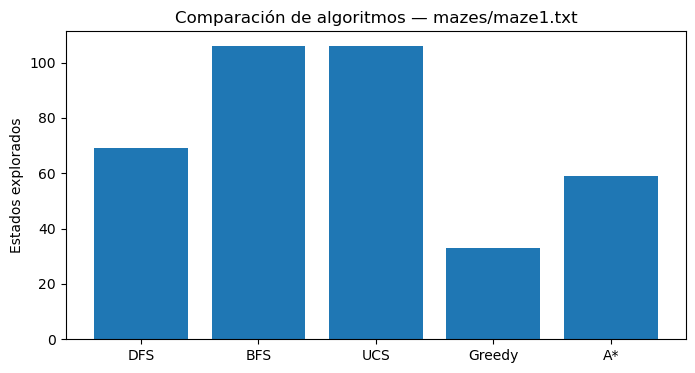

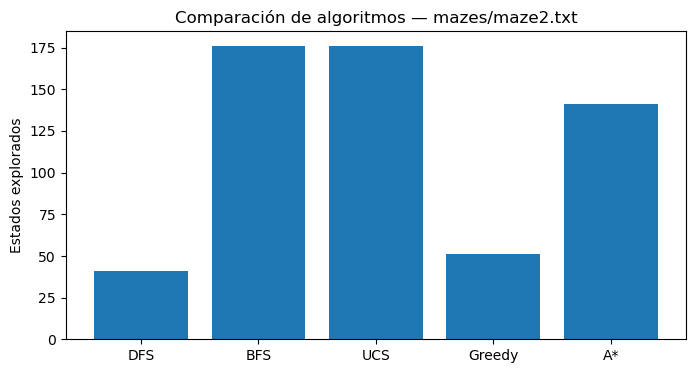

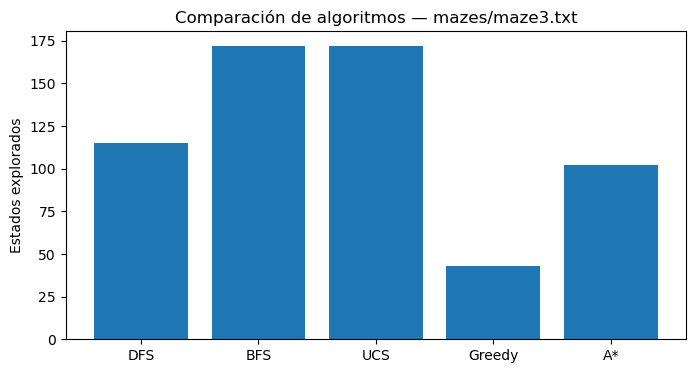

In [95]:
for filename in ["mazes/maze1.txt", "mazes/maze2.txt", "mazes/maze3.txt"]:
    rows = [row for row in all_summaries if row["laberinto"] == filename]
    labels = [row["algoritmo"] for row in rows]
    values = [row["estados_explorados"] for row in rows]

    plt.figure(figsize=(8, 4))
    plt.bar(labels, values)
    plt.ylabel("Estados explorados")
    plt.title(f"Comparación de algoritmos — {filename}")
    plt.show()

### Propiedades teóricas

| Algoritmo | Estrategia | Completo | Óptimo |
|---|---|---:|---:|
| DFS | Nodo más profundo | No, en espacios infinitos | No |
| BFS | Nodo menos profundo | Sí, con ramificación finita | Sí, con costos iguales |
| UCS | Menor \(g(n)\) | Sí, con costos positivos | Sí |
| Greedy | Menor \(h(n)\) | No siempre | No |
| A* | Menor \(g(n)+h(n)\) | Sí, bajo condiciones estándar | Sí, con heurística admisible |

La eficiencia observada depende de la estructura de cada laberinto y del orden en que `neighbors()` genera las direcciones.

## Reto de implementación (extensión conceptual, no evaluada)

Elige **una** de estas variantes y formalízala como problema de búsqueda antes de tocar código:

- movimientos diagonales;
- llaves y puertas;
- múltiples metas;
- celdas con costos distintos por dirección de entrada;
- un enemigo que cambia de posición en cada paso del agente.

Para la variante elegida, especifica por escrito:

1. **Estado:** ¿qué información mínima necesitas para que el estado determine completamente el comportamiento futuro? (Pista: si eliges "enemigo que se mueve", la posición del agente sola ya no basta — el estado también debe incluir la posición del enemigo.)
2. **Acciones** disponibles en cada estado.
3. **Modelo de transición.**
4. **Costo de cada acción.**
5. **Heurística propuesta** y si es admisible: da un argumento, no solo una intuición.

## Cierre

Las búsquedas no informadas (DFS, BFS, UCS) utilizan únicamente la estructura del problema. Las búsquedas informadas (Greedy, A*) incorporan conocimiento adicional mediante una heurística.

Lo que debería quedar claro después de este notebook:

- **El algoritmo no cambió entre el grafo y el laberinto.** Cambió la representación del problema (`graph[state]` → `maze.neighbors(state)`) y cómo se calcula la heurística (tabla fija → función de la coordenada).
- **Greedy y A* ponderado comparten el mismo defecto:** ignoran (total o parcialmente) el costo ya acumulado, y por eso pueden caer en rutas subóptimas cuando la heurística "promete" de más.
- **UCS y A* con heurística admisible son los únicos con garantía de optimalidad** cuando los costos no son uniformes.

La elección del algoritmo en un problema real depende de: si necesitamos una solución óptima, si los costos son uniformes, cuánta memoria tenemos, qué tan buena es la heurística, y qué tan grande es el espacio de estados.